# City Intelligence: Comparative Air Quality Analysis

## Objective

Air quality conditions vary significantly across Indian cities due to differences in industrial activity, population density, transportation infrastructure, and geographic factors.

This notebook focuses on:

* Comparing air quality across cities
* Identifying the most polluted cities
* Identifying the cleanest cities
* Evaluating AQI distributions
* Measuring long-term city-level improvements and deteriorations

The objective is to understand spatial variation in air pollution across India.


## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Load Dataset

In [ ]:
df = pd.read_csv("cleaned_aqi.csv")

## Dataset Coverage

This section identifies the number of unique cities available in the dataset and evaluates monitoring coverage.

In [3]:
df['City'].nunique()

26

In [4]:
sorted(df['City'].unique())

['Ahmedabad',
 'Aizawl',
 'Amaravati',
 'Amritsar',
 'Bengaluru',
 'Bhopal',
 'Brajrajnagar',
 'Chandigarh',
 'Chennai',
 'Coimbatore',
 'Delhi',
 'Ernakulam',
 'Gurugram',
 'Guwahati',
 'Hyderabad',
 'Jaipur',
 'Jorapokhar',
 'Kochi',
 'Kolkata',
 'Lucknow',
 'Mumbai',
 'Patna',
 'Shillong',
 'Talcher',
 'Thiruvananthapuram',
 'Visakhapatnam']

## Monitoring Coverage by City

The number of observations varies across cities.

Higher observation counts generally indicate stronger monitoring infrastructure and more reliable trend analysis.


In [5]:
city_obs = (
    df['City']
      .value_counts()
)

city_obs.head(15)

City
Delhi                 1951
Bengaluru             1910
Chennai               1884
Lucknow               1878
Hyderabad             1876
Patna                 1434
Gurugram              1431
Visakhapatnam         1171
Amritsar              1122
Jaipur                1094
Thiruvananthapuram    1052
Ahmedabad              922
Amaravati              841
Mumbai                 775
Jorapokhar             764
Name: count, dtype: int64

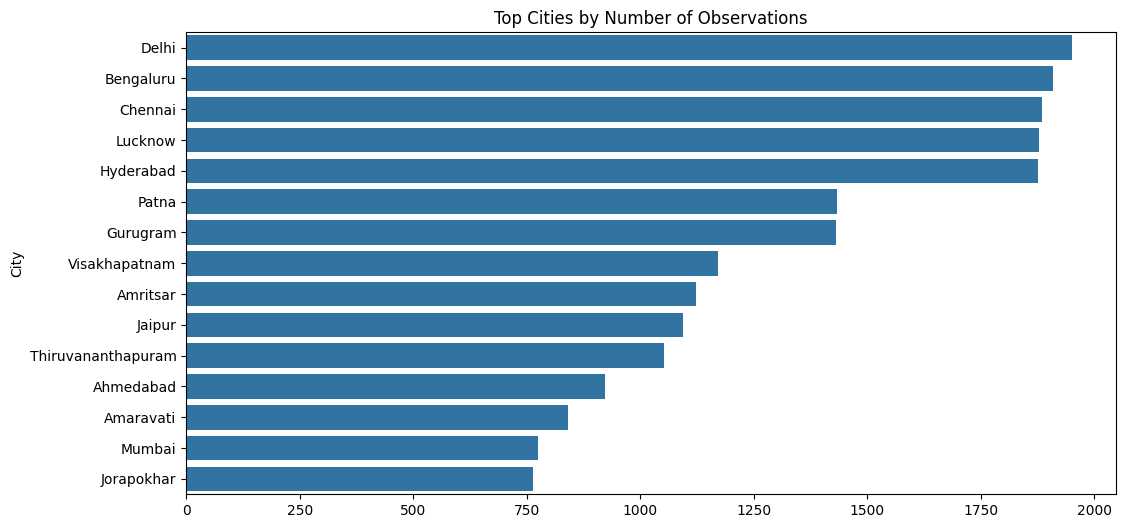

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=city_obs.head(15).values,
    y=city_obs.head(15).index
)

plt.title("Top Cities by Number of Observations")

plt.show()

## Most Polluted Cities

Average AQI is calculated for each city.

Average AQI provides a better measure of long-term exposure than isolated pollution spikes.

In [7]:
city_aqi = (
    df.groupby('City')['AQI']
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

city_aqi.head(10)

City
Ahmedabad       291.72
Delhi           252.11
Patna           235.55
Gurugram        219.41
Lucknow         215.19
Talcher         170.83
Jorapokhar      155.59
Brajrajnagar    150.28
Kolkata         140.57
Guwahati        137.04
Name: AQI, dtype: float64

In [8]:
top_polluted = city_aqi.head(10)

top_polluted

City
Ahmedabad       291.72
Delhi           252.11
Patna           235.55
Gurugram        219.41
Lucknow         215.19
Talcher         170.83
Jorapokhar      155.59
Brajrajnagar    150.28
Kolkata         140.57
Guwahati        137.04
Name: AQI, dtype: float64

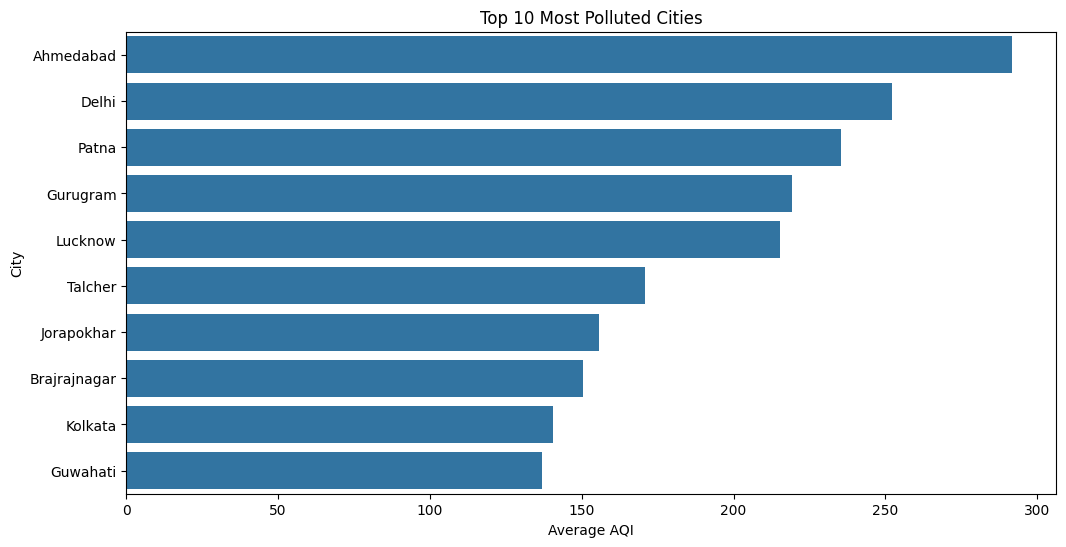

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_polluted.values,
    y=top_polluted.index
)

plt.title("Top 10 Most Polluted Cities")

plt.xlabel("Average AQI")

plt.show()

## Cleanest Cities

Cities with the lowest average AQI are identified to understand locations experiencing comparatively better air quality.

In [10]:
cleanest = city_aqi.tail(10)

cleanest

City
Mumbai                105.35
Kochi                 104.28
Chandigarh             96.50
Amaravati              95.30
Bengaluru              94.32
Ernakulam              92.36
Thiruvananthapuram     75.88
Coimbatore             73.02
Shillong               53.80
Aizawl                 34.77
Name: AQI, dtype: float64

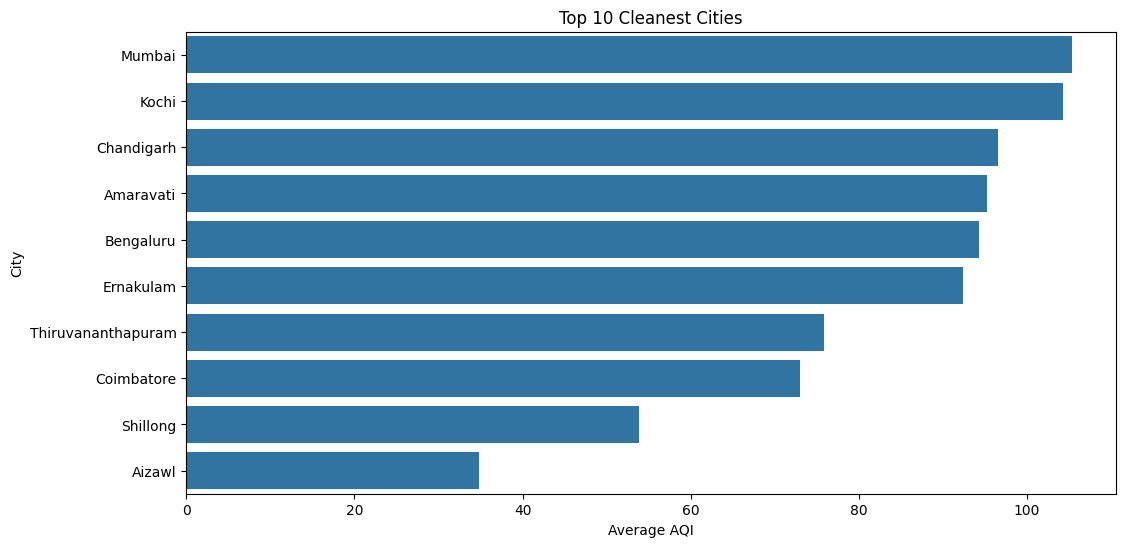

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=cleanest.values,
    y=cleanest.index
)

plt.title("Top 10 Cleanest Cities")

plt.xlabel("Average AQI")

plt.show()

## AQI Distribution Across Major Cities

While average AQI provides a summary measure, boxplots reveal:

- Median AQI
- Variability
- Extreme pollution events

This helps evaluate pollution consistency across cities.

In [12]:
top_cities = [
    'Delhi',
    'Ahmedabad',
    'Patna',
    'Lucknow',
    'Aizawl'
]

city_subset = df[
    df['City'].isin(top_cities)
]

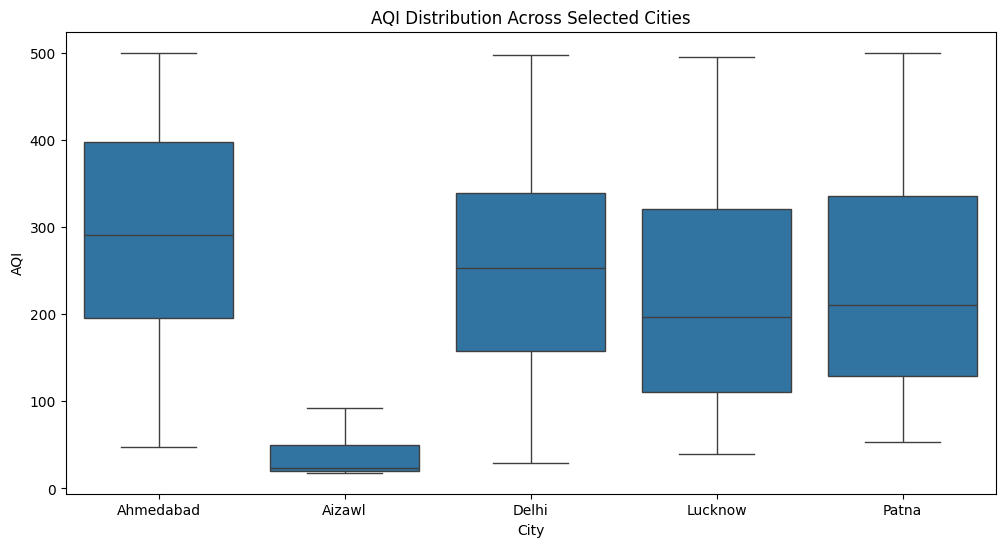

In [13]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=city_subset,
    x='City',
    y='AQI'
)

plt.title("AQI Distribution Across Selected Cities")

plt.show()

## City-Level AQI Improvement Analysis

Changes between 2015 and 2020 are calculated to identify cities that experienced the greatest improvement in air quality.


In [14]:
city_year = (
    df.groupby(['City','Year'])['AQI']
      .mean()
      .reset_index()
)

city_year.head()

,City,Year,AQI
0,Ahmedabad,2015,244.085202
1,Ahmedabad,2016,260.169811
2,Ahmedabad,2017,281.657895
3,Ahmedabad,2018,382.485549
4,Ahmedabad,2019,362.327354


In [15]:
city_pivot = (
    city_year.pivot(
        index='City',
        columns='Year',
        values='AQI'
    )
)

city_pivot.head()

Year,2015,2016,2017,2018,2019,2020
City,,,,,,
Ahmedabad,244.085202,260.169811,281.657895,382.485549,362.327354,184.176101
Aizawl,NaN,NaN,NaN,NaN,NaN,34.765766
Amaravati,NaN,NaN,192.513514,101.391026,98.485437,59.879781
Amritsar,NaN,NaN,146.592453,116.922118,109.500000,92.977011
Bengaluru,112.573427,105.584046,87.120879,86.307479,91.602740,79.715847


In [16]:
city_pivot = city_pivot.dropna(
    subset=[2015, 2020]
)

city_pivot.head()

Year,2015,2016,2017,2018,2019,2020
City,,,,,,
Ahmedabad,244.085202,260.169811,281.657895,382.485549,362.327354,184.176101
Bengaluru,112.573427,105.584046,87.120879,86.307479,91.602740,79.715847
Chennai,148.333333,138.565868,104.537396,105.490411,102.942466,80.251366
Delhi,297.024658,284.008772,248.412104,244.161560,223.135211,181.672131
Hyderabad,140.174074,121.259701,112.329609,97.556164,93.980822,78.174863


In [17]:
city_pivot['Change_%'] = (
    (city_pivot[2020] - city_pivot[2015])
    / city_pivot[2015]
) * 100

city_pivot.head()

Year,2015,2016,2017,2018,2019,2020,Change_%
City,,,,,,,
Ahmedabad,244.085202,260.169811,281.657895,382.485549,362.327354,184.176101,-24.544340
Bengaluru,112.573427,105.584046,87.120879,86.307479,91.602740,79.715847,-29.187687
Chennai,148.333333,138.565868,104.537396,105.490411,102.942466,80.251366,-45.897955
Delhi,297.024658,284.008772,248.412104,244.161560,223.135211,181.672131,-38.836010
Hyderabad,140.174074,121.259701,112.329609,97.556164,93.980822,78.174863,-44.230155


In [18]:
most_improved = (
    city_pivot
      .sort_values('Change_%')
      .head(10)
)

most_improved

Year,2015,2016,2017,2018,2019,2020,Change_%
City,,,,,,,
Patna,345.594937,240.330189,321.943262,233.634349,212.011364,162.251366,-53.051579
Chennai,148.333333,138.565868,104.537396,105.490411,102.942466,80.251366,-45.897955
Hyderabad,140.174074,121.259701,112.329609,97.556164,93.980822,78.174863,-44.230155
Delhi,297.024658,284.008772,248.412104,244.161560,223.135211,181.672131,-38.836010
Bengaluru,112.573427,105.584046,87.120879,86.307479,91.602740,79.715847,-29.187687
Ahmedabad,244.085202,260.169811,281.657895,382.485549,362.327354,184.176101,-24.544340
Lucknow,191.231884,239.230303,235.075209,233.772603,202.561644,157.125683,-17.834997


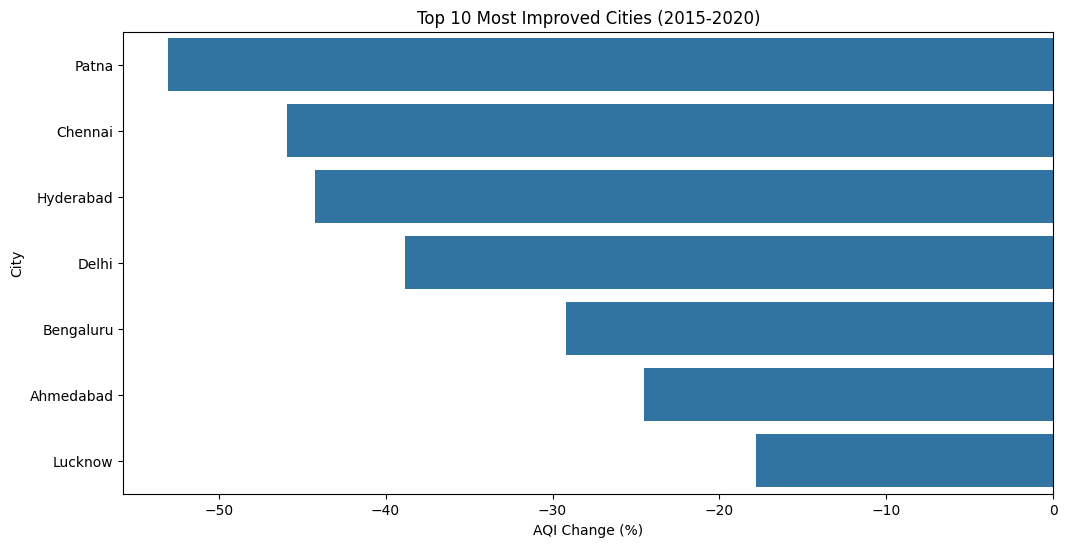

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=most_improved['Change_%'],
    y=most_improved.index
)

plt.title('Top 10 Most Improved Cities (2015-2020)')

plt.xlabel('AQI Change (%)')

plt.show()

## City-Level AQI Deterioration Analysis

Cities with increasing AQI levels are identified to highlight locations requiring greater environmental attention.

In [20]:
most_deteriorated = (
    city_pivot
      .sort_values('Change_%', ascending=False)
      .head(10)
)

most_deteriorated

Year,2015,2016,2017,2018,2019,2020,Change_%
City,,,,,,,
Lucknow,191.231884,239.230303,235.075209,233.772603,202.561644,157.125683,-17.834997
Ahmedabad,244.085202,260.169811,281.657895,382.485549,362.327354,184.176101,-24.544340
Bengaluru,112.573427,105.584046,87.120879,86.307479,91.602740,79.715847,-29.187687
Delhi,297.024658,284.008772,248.412104,244.161560,223.135211,181.672131,-38.836010
Hyderabad,140.174074,121.259701,112.329609,97.556164,93.980822,78.174863,-44.230155
Chennai,148.333333,138.565868,104.537396,105.490411,102.942466,80.251366,-45.897955
Patna,345.594937,240.330189,321.943262,233.634349,212.011364,162.251366,-53.051579


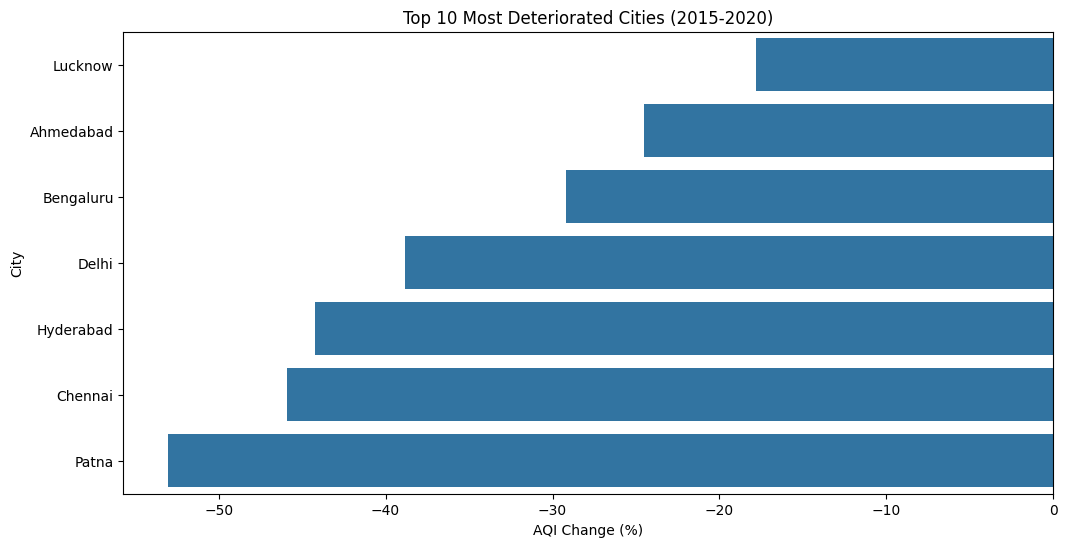

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=most_deteriorated['Change_%'],
    y=most_deteriorated.index
)

plt.title('Top 10 Most Deteriorated Cities (2015-2020)')

plt.xlabel('AQI Change (%)')

plt.show()


## City Air Quality Ranking

To compare pollution levels across locations, cities are ranked based on their average AQI.

Average AQI is used instead of individual observations because it provides a more stable representation of long-term air quality conditions.

Higher average AQI values indicate consistently poorer air quality and greater exposure to pollution.

In [22]:
city_ranking = (
    df.groupby('City')['AQI']
      .mean()
      .round(2)
      .reset_index()
      .sort_values('AQI', ascending=False)
)

city_ranking['Rank'] = range(
    1,
    len(city_ranking)+1
)

city_ranking = city_ranking[
    ['Rank','City','AQI']
]

city_ranking.head(15)

,Rank,City,AQI
0,1,Ahmedabad,291.72
10,2,Delhi,252.11
21,3,Patna,235.55
12,4,Gurugram,219.41
19,5,Lucknow,215.19
23,6,Talcher,170.83
16,7,Jorapokhar,155.59
6,8,Brajrajnagar,150.28
18,9,Kolkata,140.57
13,10,Guwahati,137.04


## AQI Category Composition by City

While average AQI provides an overall measure of pollution, it does not reveal how frequently cities experience different pollution categories.

This analysis evaluates the distribution of observations across AQI categories such as:

- Good
- Satisfactory
- Moderate
- Poor
- Very Poor
- Severe

The objective is to understand pollution consistency and severity across cities.

In [23]:
city_bucket = (
    pd.crosstab(
        df['City'],
        df['AQI_Bucket']
    )
)

city_bucket.head()

AQI_Bucket,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
City,,,,,,
Ahmedabad,1,198,238,43,226,216
Aizawl,83,0,0,28,0,0
Amaravati,158,219,47,409,0,8
Amritsar,84,448,67,473,3,47
Bengaluru,115,630,36,1124,0,5


### Key Observation

Cities differ not only in average AQI but also in pollution distribution.

Some cities experience frequent Severe and Very Poor air quality episodes, while others spend most of the year within Good or Moderate categories.

## AQI Category Heatmap

A heatmap is used to visualize how pollution categories are distributed across cities.

This approach enables rapid identification of:

- High-risk cities
- Frequently occurring pollution categories
- Regional differences in air quality patterns

Darker regions represent a greater concentration of observations within a particular AQI category.

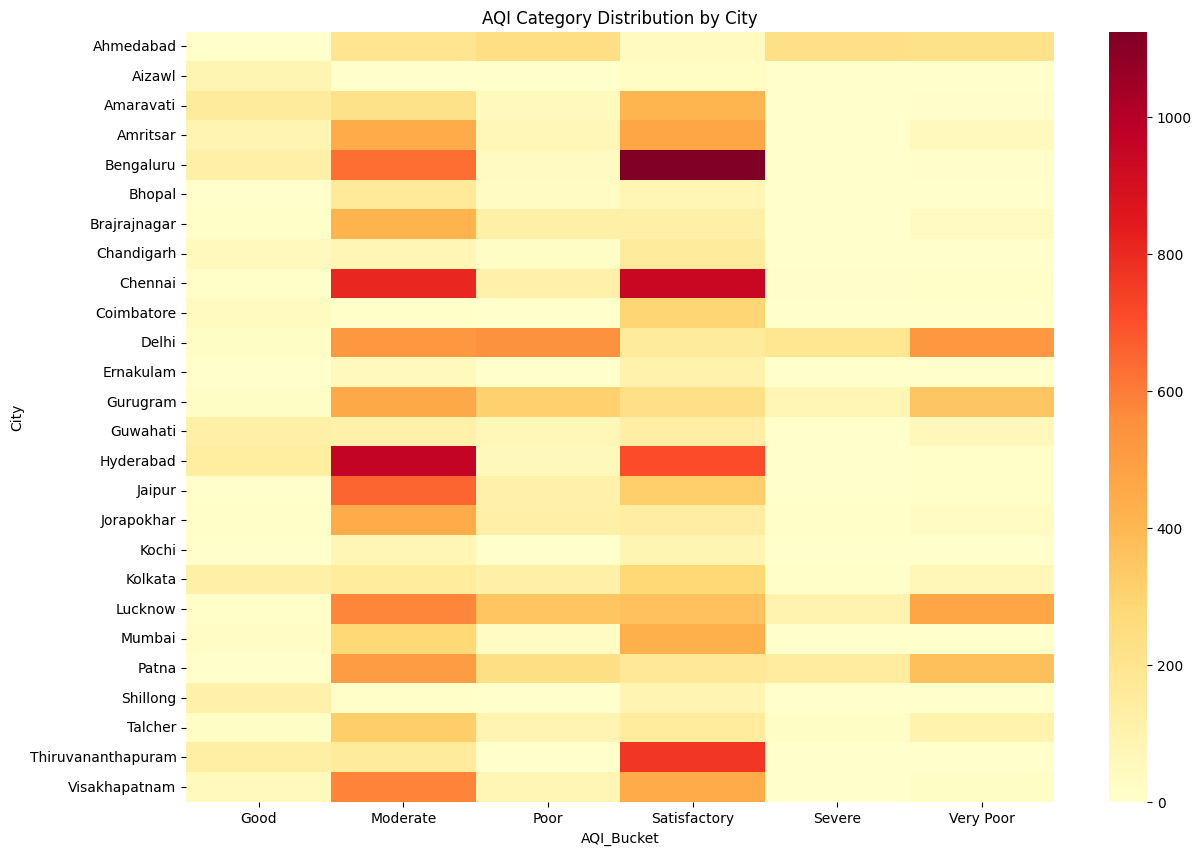

In [24]:
plt.figure(figsize=(14,10))

sns.heatmap(
    city_bucket,
    cmap='YlOrRd'
)

plt.title(
    'AQI Category Distribution by City'
)

plt.show()

# Key Findings

1. Ahmedabad recorded the highest average AQI (291.72), making it the most polluted city in the dataset.

2. Aizawl recorded the lowest average AQI (34.77), making it the cleanest city.

3. The pollution burden in Ahmedabad was approximately 8.4 times higher than in Aizawl.

4. Significant differences in AQI distributions exist across Indian cities, indicating strong regional variability in air quality.

5. Several cities exhibited measurable improvements between 2015 and 2020, while others experienced deteriorating air quality trends.